In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
data=pd.read_csv("./crop_production.csv")

In [23]:
#checking for null values
data.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

In [24]:
data.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [25]:
#1.State Names

no_of_states=data['State_Name'].unique()
print(no_of_states)
print('Total Availabe States in Datasets:',len(no_of_states))


['Andaman and Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh' 'Dadra and Nagar Haveli'
 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu and Kashmir '
 'Jharkhand' 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur'
 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana ' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal']
Total Availabe States in Datasets: 33


In [26]:
#2.District names
district=data['District_Name'].unique()
data[data['State_Name']=='Uttar Pradesh']['District_Name'].unique()



array(['AGRA', 'ALIGARH', 'ALLAHABAD', 'AMBEDKAR NAGAR', 'AMETHI',
       'AMROHA', 'AURAIYA', 'AZAMGARH', 'BAGHPAT', 'BAHRAICH', 'BALLIA',
       'BALRAMPUR', 'BANDA', 'BARABANKI', 'BAREILLY', 'BASTI', 'BIJNOR',
       'BUDAUN', 'BULANDSHAHR', 'CHANDAULI', 'CHITRAKOOT', 'DEORIA',
       'ETAH', 'ETAWAH', 'FAIZABAD', 'FARRUKHABAD', 'FATEHPUR',
       'FIROZABAD', 'GAUTAM BUDDHA NAGAR', 'GHAZIABAD', 'GHAZIPUR',
       'GONDA', 'GORAKHPUR', 'HAMIRPUR', 'HAPUR', 'HARDOI', 'HATHRAS',
       'JALAUN', 'JAUNPUR', 'JHANSI', 'KANNAUJ', 'KANPUR DEHAT',
       'KANPUR NAGAR', 'KASGANJ', 'KAUSHAMBI', 'KHERI', 'KUSHI NAGAR',
       'LALITPUR', 'LUCKNOW', 'MAHARAJGANJ', 'MAHOBA', 'MAINPURI',
       'MATHURA', 'MAU', 'MEERUT', 'MIRZAPUR', 'MORADABAD',
       'MUZAFFARNAGAR', 'PILIBHIT', 'PRATAPGARH', 'RAE BARELI', 'RAMPUR',
       'SAHARANPUR', 'SAMBHAL', 'SANT KABEER NAGAR', 'SANT RAVIDAS NAGAR',
       'SHAHJAHANPUR', 'SHAMLI', 'SHRAVASTI', 'SIDDHARTH NAGAR',
       'SITAPUR', 'SONBHADRA', 'SULTAN

In [27]:
#3. Crop Year

years = data['Crop_Year'].unique()
years

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2010, 1997, 1998, 1999,
       2007, 2008, 2009, 2011, 2012, 2013, 2014, 2015])

In [28]:
#4. Season
total_seasons=data['Season'].str.strip()
data['Season']=total_seasons
print(data['Season'].unique())

['Kharif' 'Whole Year' 'Autumn' 'Rabi' 'Summer' 'Winter']


In [29]:
#5. Crop
data['Crop'] = data['Crop'].str.strip()
print(len(data['Crop'].unique()),'\n',data['Crop'])
# crop

124 
 0                    Arecanut
1         Other Kharif pulses
2                        Rice
3                      Banana
4                   Cashewnut
                 ...         
246086                   Rice
246087                Sesamum
246088              Sugarcane
246089                   Rice
246090                Sesamum
Name: Crop, Length: 246091, dtype: object


In [30]:
production=data['Production'].isnull().sum()

#3730 rows are missing so droping these rows
# %of production column
print((production/246091)*100)

newdata=data.dropna()
print("No of remaining rows:",len(newdata))

1.5156994770227274
No of remaining rows: 242361


In [31]:
newdata.isnull().sum()
newdata.dtypes

State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object

In [32]:
newdata['yield']=newdata['Production']/(newdata['Area']+0.0001)
newdatas=newdata.drop(columns=['Production', 'Area'], inplace=False)

C:\Users\2k22c\AppData\Local\Temp\ipykernel_22344\2684758875.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  newdata['yield']=newdata['Production']/(newdata['Area']+0.0001)


In [33]:
def recommend_top_crops(df, state, district, season,best_crops_choice):
    df['Production_by_Area'] = df['Production'] / (df['Area'] + 0.0000001)
    filtered = df[
        (df['State_Name'] == state) &
        (df['District_Name'] == district) &
        (df['Season'] == season)
    ]
    filtered.head()
    top_crops=[[]]
    if best_crops_choice==True:
        top_crops = (
            filtered.groupby('Crop')['Production_by_Area']
            .mean()
            .sort_values(ascending=False)
            .head(10)
    )
    else:
        top_crops = (
            filtered.groupby('Crop')['Production_by_Area']
            .mean()
            .sort_values(ascending=False)
    )
    return top_crops.reset_index()
best_crops_choice=True
recommended_crops=recommend_top_crops(newdata, 'Uttar Pradesh', 'KANPUR NAGAR', 'Kharif',best_crops_choice)
#print(c)
# West Bengal	DINAJPUR DAKSHIN	2004	Summer	Rice	40173.0	118905.0
# Uttar Pradesh	AGRA	1997	Kharif	Arhar/Tur	6538.0	9664.0
recommended_crops

C:\Users\2k22c\AppData\Local\Temp\ipykernel_22344\1998766731.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Production_by_Area'] = df['Production'] / (df['Area'] + 0.0000001)


,Crop,Production_by_Area
0,Sugarcane,45.684057
1,Sweet potato,12.983346
2,Onion,6.447266
3,Dry ginger,4.906250
4,Total foodgrain,2.235285
5,Sunflower,2.178947
6,Rice,2.118611
7,Arhar/Tur,1.905738
8,Bajra,1.569203
9,Maize,1.511642


C:\Users\2k22c\AppData\Local\Temp\ipykernel_22344\1470346253.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Production_by_Area', y='Crop', data=recommended_crops, palette='viridis')


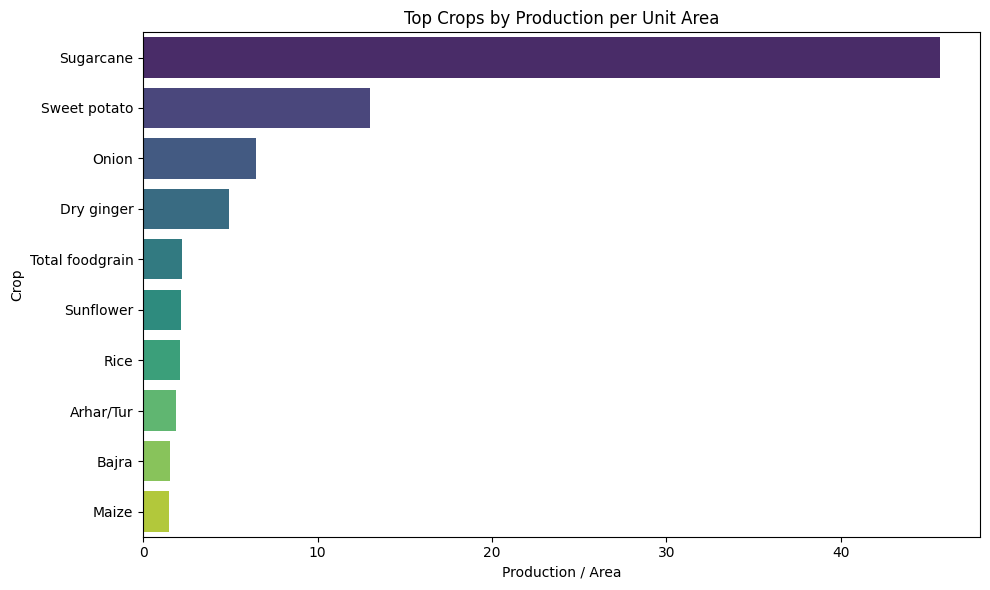

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Production_by_Area', y='Crop', data=recommended_crops, palette='viridis')
plt.title('Top Crops by Production per Unit Area')
plt.xlabel('Production / Area')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()